In [23]:
import pandas as pd

# Path to your Excel file
file_path = "DS.xlsx"

# Select columns by their names (list)
df = pd.read_excel(file_path)

udf = df[(df['facecount'] == 1) & (df['error'] == 0)]
udf=udf.drop(columns=['facecount', 'error'])
print(udf.columns)
print(len(udf[udf['fake'] == 0]), len(udf[udf['fake'] == 1]))

Index(['fl', 'fr', 'rl', 'peakscf', 'peakscl', 'peakscr', 'maxif', 'maxil',
       'maxir', 'avgif', 'avgil', 'avgir', 'commonpeaksc', 'fake'],
      dtype='object')
372 761


# Decision Tree Classifier

Accuracy: 0.6387665198237885
Precision: 0.6586990102408605
Recall: 0.6387665198237885
F1 Score: 0.647083108614411
Confusion Matrix:
[[ 30  35]
 [ 47 115]]
Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.46      0.42        65
           1       0.77      0.71      0.74       162

    accuracy                           0.64       227
   macro avg       0.58      0.59      0.58       227
weighted avg       0.66      0.64      0.65       227



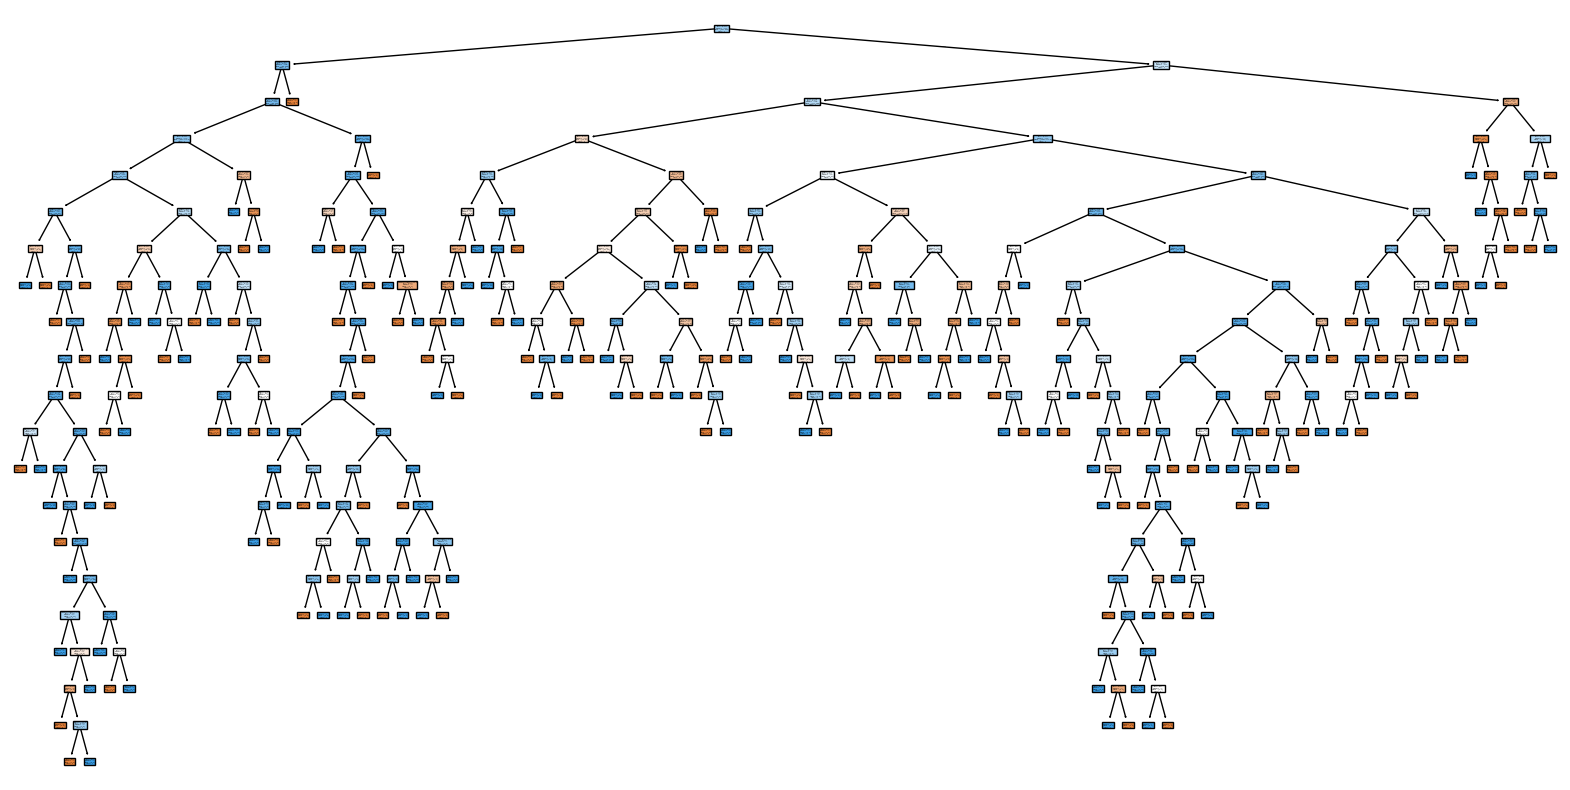

In [24]:
# Step 1: Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn import tree
import matplotlib.pyplot as plt

# Step 3: Splitting the Dataset
# Features
X = udf.drop(columns=['fake'])
# Target
y = udf['fake']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Training the Model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 5: Evaluating the Model
# Predicting on the test set
y_pred = clf.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# Calculating precision
precision = precision_score(y_test, y_pred, average='weighted')
print(f'Precision: {precision}')

# Calculating recall
recall = recall_score(y_test, y_pred, average='weighted')
print(f'Recall: {recall}')

# Calculating F1 score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'F1 Score: {f1}')

# Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Generating classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

# Visualizing the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(clf, feature_names=X.columns, class_names=['0', '1'], filled=True)
plt.show()


# Random Forest

Accuracy: 0.73568281938326
Precision: 0.709303397754281
Recall: 0.73568281938326
F1 Score: 0.7044084178243887
Confusion Matrix:
[[ 19  46]
 [ 14 148]]
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.29      0.39        65
           1       0.76      0.91      0.83       162

    accuracy                           0.74       227
   macro avg       0.67      0.60      0.61       227
weighted avg       0.71      0.74      0.70       227



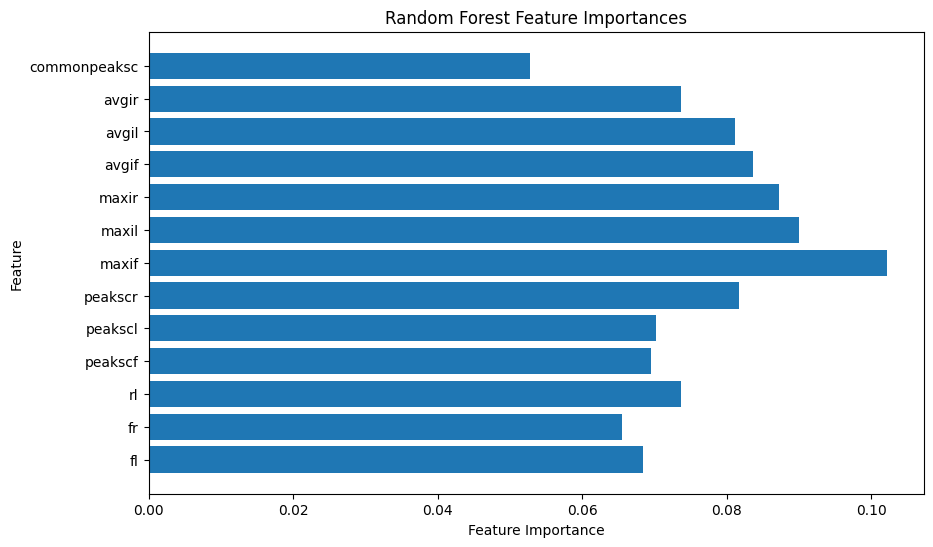

In [25]:
# Step 1: Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier  # Import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Step 2: Loading the Dataset
# Assuming the data is in a DataFrame named 'udf'
# Adjust this part according to your data loading method
X = udf.drop(columns=['fake'])  # Features
y = udf['fake']  # Target

# Step 3: Splitting the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Training the Random Forest Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)  # Initialize RandomForestClassifier with 100 trees
clf.fit(X_train, y_train)

# Step 5: Evaluating the Model
# Predicting on the test set
y_pred = clf.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# Calculating precision
precision = precision_score(y_test, y_pred, average='weighted')
print(f'Precision: {precision}')

# Calculating recall
recall = recall_score(y_test, y_pred, average='weighted')
print(f'Recall: {recall}')

# Calculating F1 score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'F1 Score: {f1}')

# Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Generating classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

# Note: Random Forests do not provide a single tree visualization like Decision Trees

# Optionally, you can visualize feature importances if needed
feature_importances = clf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.show()


# RF with Hyperparameter Tunining(Grid Search)

In [26]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize RandomForestClassifier
clf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, 
                           cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f'Best parameters: {grid_search.best_params_}')

# Get the best model
best_clf = grid_search.best_estimator_

# Evaluate the best model
y_pred = best_clf.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print metrics
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Accuracy: 0.748898678414097
Precision: 0.7322902425439262
Recall: 0.748898678414097
F1 Score: 0.705163684492809


C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
405 fits failed out of a total of 1215.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
81 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\dpava\OneDrive\Documents\Git

# SVM

Accuracy: 0.7136563876651982
Precision: 0.5093054396553397
Recall: 0.7136563876651982
F1 Score: 0.5944078910116304
Confusion Matrix:
[[  0  65]
 [  0 162]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        65
           1       0.71      1.00      0.83       162

    accuracy                           0.71       227
   macro avg       0.36      0.50      0.42       227
weighted avg       0.51      0.71      0.59       227



C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter t

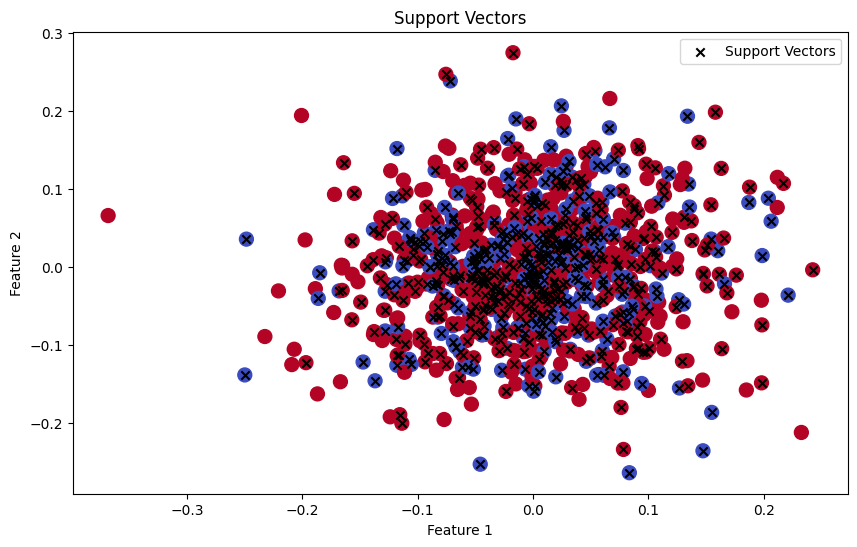

In [27]:
# Step 1: Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC  # Import Support Vector Classifier (SVC)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Step 2: Loading the Dataset
# Assuming the data is in a DataFrame named 'udf'
# Adjust this part according to your data loading method
X = udf.drop(columns=['fake'])  # Features
y = udf['fake']  # Target

# Step 3: Splitting the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Training the SVM Model
clf = SVC(kernel='rbf', random_state=42)  # Initialize Support Vector Classifier (SVC) with RBF kernel
clf.fit(X_train, y_train)

# Step 5: Evaluating the Model
# Predicting on the test set
y_pred = clf.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# Calculating precision
precision = precision_score(y_test, y_pred, average='weighted')
print(f'Precision: {precision}')

# Calculating recall
recall = recall_score(y_test, y_pred, average='weighted')
print(f'Recall: {recall}')

# Calculating F1 score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'F1 Score: {f1}')

# Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Generating classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

# Note: SVMs do not provide direct feature importances or decision tree visualization

# Optionally, you can visualize support vectors if needed
# Uncomment below lines if you want to visualize support vectors
plt.figure(figsize=(10, 6))
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, cmap='coolwarm', s=100)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], color='k', marker='x', label='Support Vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Support Vectors')
plt.show()


# GBM

[LightGBM] [Info] Number of positive: 599, number of negative: 307
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2595
[LightGBM] [Info] Number of data points in the train set: 906, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.661148 -> initscore=0.668414
[LightGBM] [Info] Start training from score 0.668414
Accuracy: 0.73568281938326
Precision: 0.7158886145670287
Recall: 0.73568281938326
F1 Score: 0.7193376237531549
Confusion Matrix:
[[ 25  40]
 [ 20 142]]
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.38      0.45        65
           1       0.78      0.88      0.83       162

    accuracy                           0.74       227
   macro avg       0.67      0.63      0.64       227
weighted avg       0.72      0.74      0.72       227



<Figure size 1000x600 with 0 Axes>

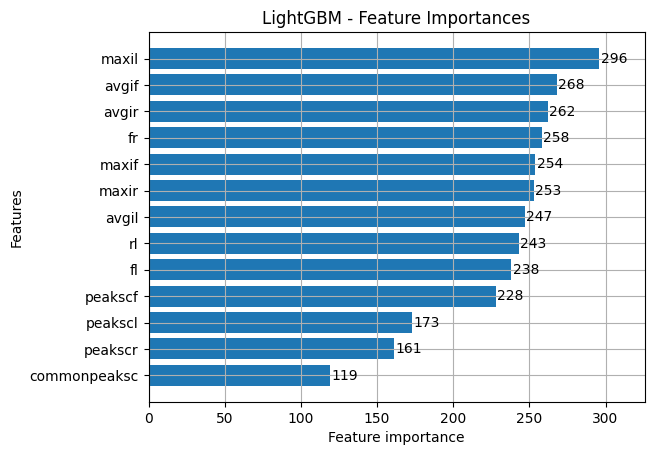

In [28]:
# Step 1: Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import lightgbm as lgb  # Import LightGBM
import matplotlib.pyplot as plt

# Step 2: Loading the Dataset
# Assuming the data is in a DataFrame named 'udf'
# Adjust this part according to your data loading method
X = udf.drop(columns=['fake'])  # Features
y = udf['fake']  # Target

# Step 3: Splitting the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Training the GBM Model
clf = lgb.LGBMClassifier(random_state=42)  # Initialize LightGBM classifier
clf.fit(X_train, y_train)

# Step 5: Evaluating the Model
# Predicting on the test set
y_pred = clf.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# Calculating precision
precision = precision_score(y_test, y_pred, average='weighted')
print(f'Precision: {precision}')

# Calculating recall
recall = recall_score(y_test, y_pred, average='weighted')
print(f'Recall: {recall}')

# Calculating F1 score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'F1 Score: {f1}')

# Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Generating classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

# Visualizing feature importances
plt.figure(figsize=(10, 6))
lgb.plot_importance(clf, height=0.8)
plt.title("LightGBM - Feature Importances")
plt.show()

# ALL MODELS

Decision Tree Metrics:
Accuracy: 0.6387665198237885
Precision: 0.6586990102408605
Recall: 0.6387665198237885
F1 Score: 0.647083108614411
------------------------------------
Random Forest Metrics:
Accuracy: 0.73568281938326
Precision: 0.709303397754281
Recall: 0.73568281938326
F1 Score: 0.7044084178243887
------------------------------------
SVM Metrics:
Accuracy: 0.7136563876651982
Precision: 0.5093054396553397
Recall: 0.7136563876651982
F1 Score: 0.5944078910116304
------------------------------------
[LightGBM] [Info] Number of positive: 599, number of negative: 307
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000367 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2595
[LightGBM] [Info] Number of data points in the train set: 906, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.661148 -> initscore=0.668414
[LightGBM] [Info] Start training from score 0.668414
Light

C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


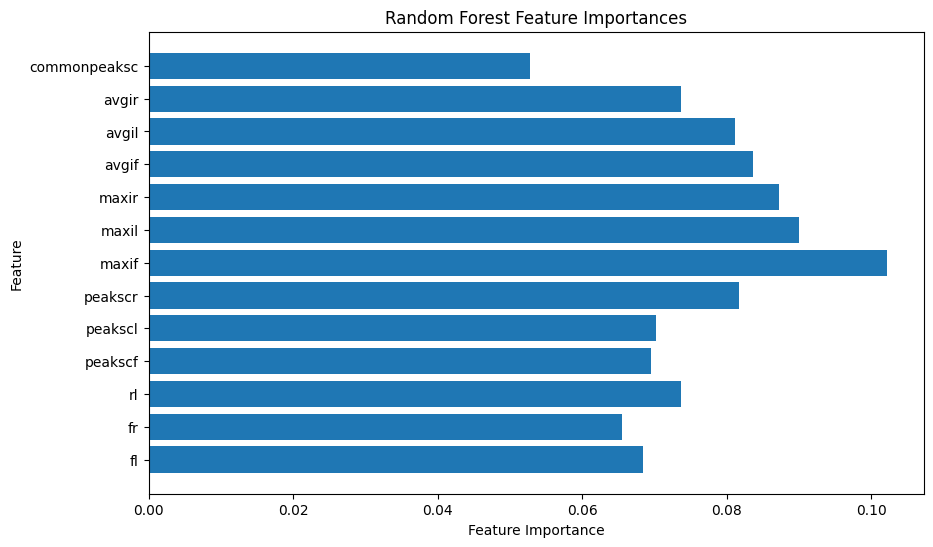

<Figure size 1000x600 with 0 Axes>

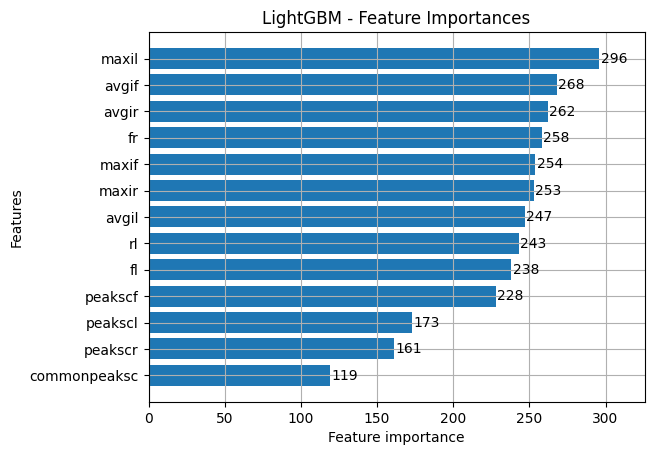

In [29]:
# Step 1: Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import lightgbm as lgb
import matplotlib.pyplot as plt

# Assuming the data is in a DataFrame named 'udf'
# Adjust this part according to your data loading method
X = udf.drop(columns=['fake'])  # Features
y = udf['fake']  # Target

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models initialization
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

# Dictionary to store results
results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

# Training, evaluating each model and storing results
for model_name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    
    # Predicting on the test set
    y_pred = model.predict(X_test)
    
    # Metrics calculation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Storing results
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)
    
    # Printing metrics
    print(f"{model_name} Metrics:")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print("------------------------------------")

# Creating a DataFrame for results
results_df = pd.DataFrame(results)

# Displaying results table
print("\nResults Summary:")
print(results_df)

# Optionally, you can visualize additional plots if needed (e.g., confusion matrix, feature importance)

# Example: Confusion Matrix for Decision Tree
clf_dt = models['Decision Tree']
y_pred_dt = clf_dt.predict(X_test)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix (Decision Tree):")
print(conf_matrix_dt)

# Example: Feature Importance for Random Forest
clf_rf = models['Random Forest']
feature_importances = clf_rf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.show()

# Example: Feature Importance for LightGBM
clf_gbm = models['LightGBM']
plt.figure(figsize=(10, 6))
lgb.plot_importance(clf_gbm, height=0.8)
plt.title("LightGBM - Feature Importances")
plt.show()


Decision Tree Metrics:
Accuracy: 0.6387665198237885
Precision: 0.6586990102408605
Recall: 0.6387665198237885
F1 Score: 0.647083108614411
------------------------------------
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.39      0.46      0.42        65
           1       0.77      0.71      0.74       162

    accuracy                           0.64       227
   macro avg       0.58      0.59      0.58       227
weighted avg       0.66      0.64      0.65       227

------------------------------------
Random Forest Metrics:
Accuracy: 0.73568281938326
Precision: 0.709303397754281
Recall: 0.73568281938326
F1 Score: 0.7044084178243887
------------------------------------
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.58      0.29      0.39        65
           1       0.76      0.91      0.83       162

    accuracy                           0.74   

C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter t

GBM Metrics:
Accuracy: 0.7444933920704846
Precision: 0.7216591180894737
Recall: 0.7444933920704846
F1 Score: 0.7142614705635756
------------------------------------
Classification Report for GBM:
              precision    recall  f1-score   support

           0       0.61      0.31      0.41        65
           1       0.77      0.92      0.84       162

    accuracy                           0.74       227
   macro avg       0.69      0.61      0.62       227
weighted avg       0.72      0.74      0.71       227

------------------------------------

Results Summary:
           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree  0.638767   0.658699  0.638767  0.647083
1  Random Forest  0.735683   0.709303  0.735683  0.704408
2            SVM  0.713656   0.509305  0.713656  0.594408
3            GBM  0.744493   0.721659  0.744493  0.714261

Confusion Matrix (Decision Tree):
[[ 30  35]
 [ 47 115]]


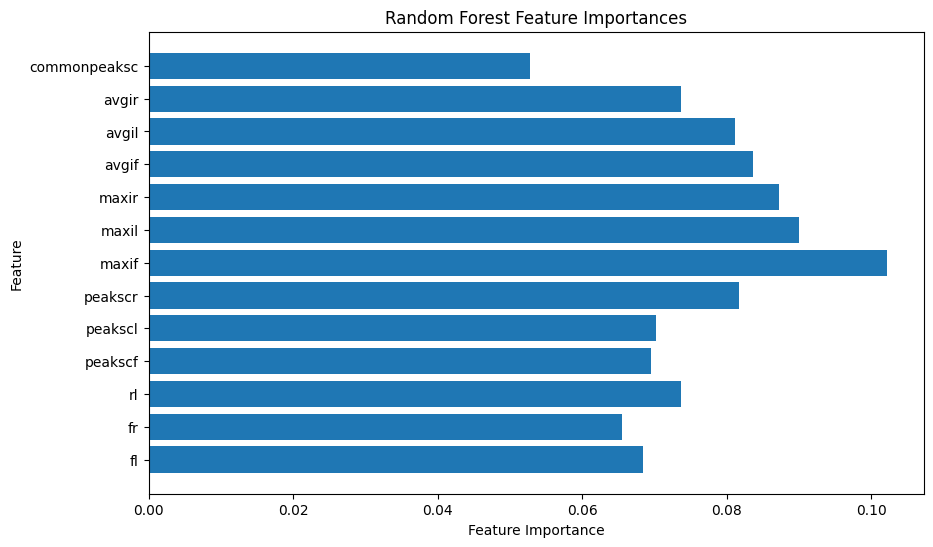

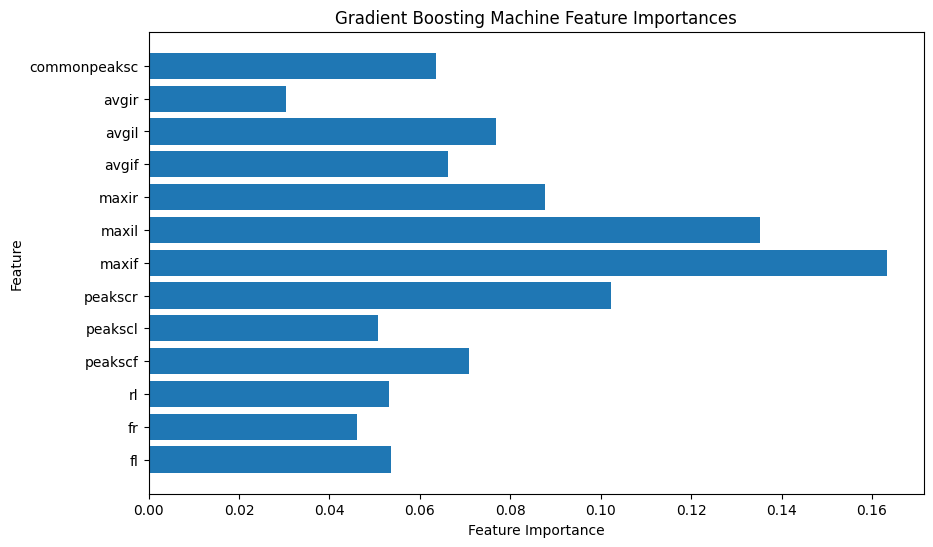

In [30]:
# Step 1: Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Assuming the data is in a DataFrame named 'udf'
# Adjust this part according to your data loading method
X = udf.drop(columns=['fake'])  # Features
y = udf['fake']  # Target

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models initialization
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "GBM": GradientBoostingClassifier(random_state=42)
}

# Dictionary to store results
results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

# Training, evaluating each model and storing results
for model_name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    
    # Predicting on the test set
    y_pred = model.predict(X_test)
    
    # Metrics calculation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Storing results
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)
    
    # Printing metrics
    print(f"{model_name} Metrics:")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print("------------------------------------")
    
    # Printing classification report
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred))
    print("------------------------------------")

# Creating a DataFrame for results
results_df = pd.DataFrame(results)

# Displaying results table
print("\nResults Summary:")
print(results_df)

# Optionally, you can visualize additional plots if needed (e.g., confusion matrix, feature importance)

# Example: Confusion Matrix for Decision Tree
clf_dt = models['Decision Tree']
y_pred_dt = clf_dt.predict(X_test)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix (Decision Tree):")
print(conf_matrix_dt)

# Example: Feature Importance for Random Forest
clf_rf = models['Random Forest']
feature_importances = clf_rf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.show()

# Example: Feature Importance for GBM
clf_gbm = models['GBM']
feature_importances_gbm = clf_gbm.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances_gbm)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Gradient Boosting Machine Feature Importances')
plt.show()

In [31]:
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Load dataset (assuming 'udf' is your DataFrame)
# df = pd.read_csv('dataset.csv')

# Separate features and target
X = udf.drop(columns=['fake'])  # Features
y = udf['fake']  # Target

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features if needed (example using StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize AdaBoost classifier with GridSearchCV for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

grid_search = GridSearchCV(estimator=AdaBoostClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=1)
   
grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print(f'Best parameters found: {best_params}')

# Fit AdaBoost classifier with best parameters
adaboost_clf = best_estimator
adaboost_clf.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = adaboost_clf.predict(X_test_scaled)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Fitting 5 folds for each of 9 candidates, totalling 45 fits


C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boostin

Best parameters found: {'learning_rate': 0.1, 'n_estimators': 100}


C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.72
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.17      0.26        65
           1       0.74      0.94      0.83       162

    accuracy                           0.72       227
   macro avg       0.64      0.56      0.54       227
weighted avg       0.68      0.72      0.67       227

Confusion Matrix:
[[ 11  54]
 [  9 153]]


Decision Tree Metrics:
Accuracy: 0.6123348017621145
Precision: 0.6332696378511357
Recall: 0.6123348017621145
F1 Score: 0.6212599214398556
------------------------------------
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.35      0.42      0.38        65
           1       0.75      0.69      0.72       162

    accuracy                           0.61       227
   macro avg       0.55      0.55      0.55       227
weighted avg       0.63      0.61      0.62       227

------------------------------------
Random Forest Metrics:
Accuracy: 0.7180616740088106
Precision: 0.7130046871968266
Recall: 0.7180616740088106
F1 Score: 0.7153055986192336
------------------------------------
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.51      0.48      0.49        65
           1       0.80      0.81      0.80       162

    accuracy                           0

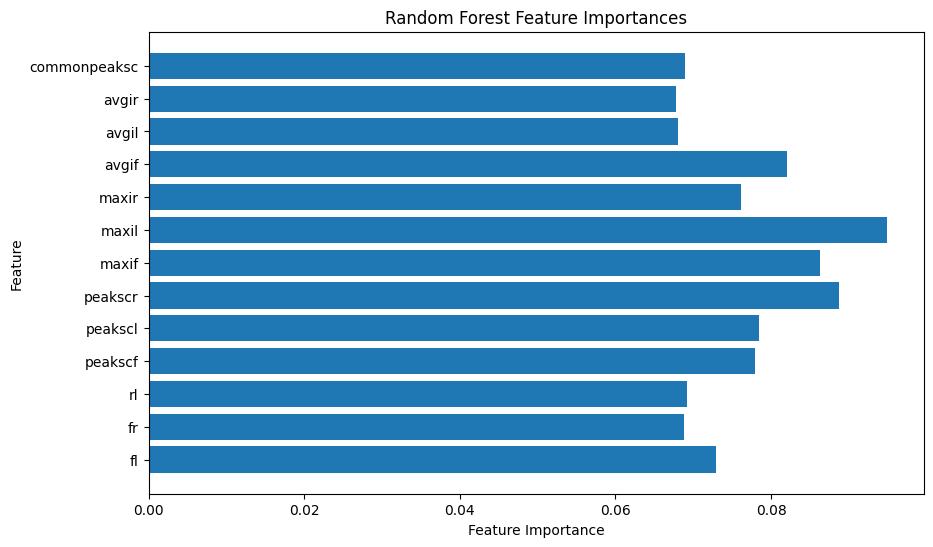

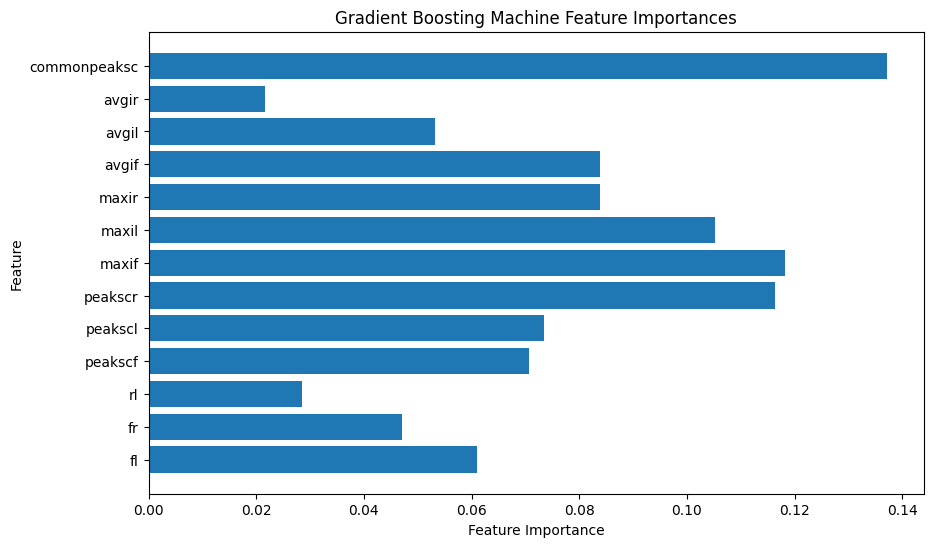

In [32]:
# Step 1: Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE  # Importing SMOTE
import matplotlib.pyplot as plt

# Assuming the data is in a DataFrame named 'udf'
# Adjust this part according to your data loading method
X = udf.drop(columns=['fake'])  # Features
y = udf['fake']  # Target

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Models initialization with class weight adjustment
models = {
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', class_weight='balanced', random_state=42),
    "GBM": GradientBoostingClassifier(random_state=42)  # GBM does not have class_weight parameter
}

# Dictionary to store results
results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

# Training, evaluating each model and storing results
for model_name, model in models.items():
    # Training
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predicting on the test set
    y_pred = model.predict(X_test)
    
    # Metrics calculation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Storing results
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)
    
    # Printing metrics
    print(f"{model_name} Metrics:")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print("------------------------------------")
    
    # Printing classification report
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred))
    print("------------------------------------")

# Creating a DataFrame for results
results_df = pd.DataFrame(results)

# Displaying results table
print("\nResults Summary:")
print(results_df)

# Optionally, you can visualize additional plots if needed (e.g., confusion matrix, feature importance)

# Example: Confusion Matrix for Decision Tree
clf_dt = models['Decision Tree']
y_pred_dt = clf_dt.predict(X_test)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix (Decision Tree):")
print(conf_matrix_dt)

# Example: Feature Importance for Random Forest
clf_rf = models['Random Forest']
feature_importances = clf_rf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.show()

# Example: Feature Importance for GBM
clf_gbm = models['GBM']
feature_importances_gbm = clf_gbm.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances_gbm)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Gradient Boosting Machine Feature Importances')
plt.show()


Decision Tree Metrics:
Accuracy: 0.6123348017621145
Precision: 0.6332696378511357
Recall: 0.6123348017621145
F1 Score: 0.6212599214398556
------------------------------------
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.35      0.42      0.38        65
           1       0.75      0.69      0.72       162

    accuracy                           0.61       227
   macro avg       0.55      0.55      0.55       227
weighted avg       0.63      0.61      0.62       227

------------------------------------
Random Forest Metrics:
Accuracy: 0.7180616740088106
Precision: 0.7130046871968266
Recall: 0.7180616740088106
F1 Score: 0.7153055986192336
------------------------------------
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.51      0.48      0.49        65
           1       0.80      0.81      0.80       162

    accuracy                           0

C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


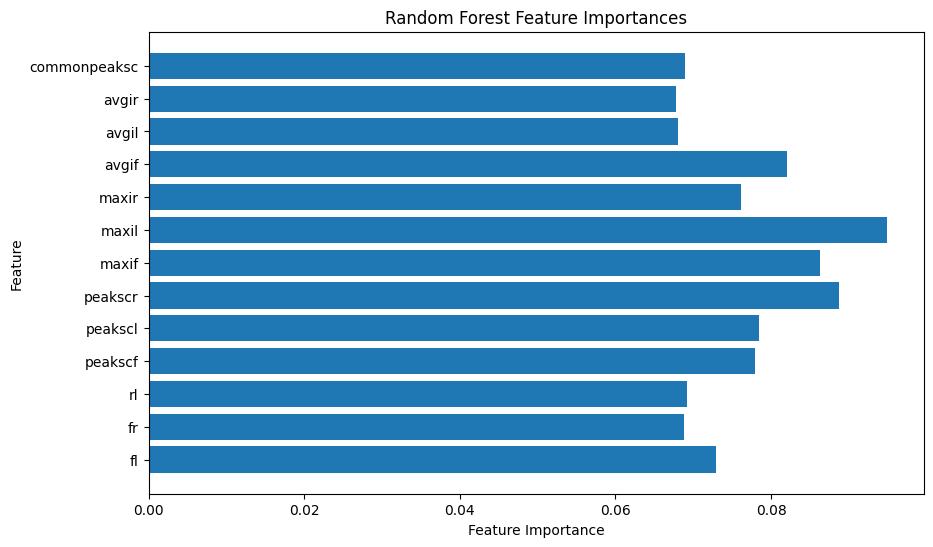

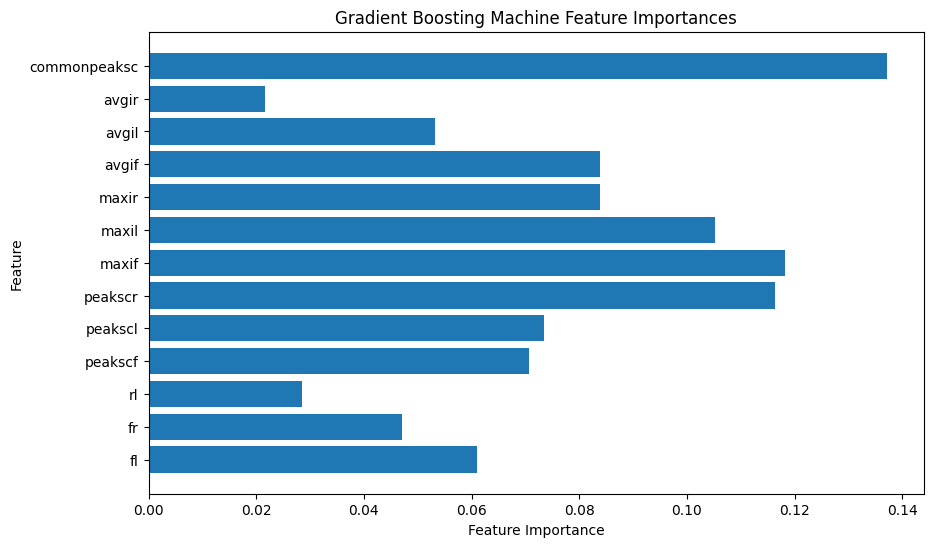

In [33]:
# Step 1: Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE  # Importing SMOTE
import matplotlib.pyplot as plt

# Assuming the data is in a DataFrame named 'udf'
# Adjust this part according to your data loading method
X = udf.drop(columns=['fake'])  # Features
y = udf['fake']  # Target

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Models initialization with class weight adjustment
models = {
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', class_weight='balanced', random_state=42),
    "GBM": GradientBoostingClassifier(random_state=42),  # GBM does not have class_weight parameter
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
                                   n_estimators=50, random_state=42)
}

# Dictionary to store results
results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

# Training, evaluating each model and storing results
for model_name, model in models.items():
    # Training
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predicting on the test set
    y_pred = model.predict(X_test)
    
    # Metrics calculation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Storing results
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)
    
    # Printing metrics
    print(f"{model_name} Metrics:")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print("------------------------------------")
    
    # Printing classification report
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred))
    print("------------------------------------")

# Creating a DataFrame for results
results_df = pd.DataFrame(results)

# Displaying results table
print("\nResults Summary:")
print(results_df)

# Optionally, you can visualize additional plots if needed (e.g., confusion matrix, feature importance)

# Example: Confusion Matrix for Decision Tree
clf_dt = models['Decision Tree']
y_pred_dt = clf_dt.predict(X_test)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix (Decision Tree):")
print(conf_matrix_dt)

# Example: Feature Importance for Random Forest
clf_rf = models['Random Forest']
feature_importances = clf_rf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.show()

# Example: Feature Importance for GBM
clf_gbm = models['GBM']
feature_importances_gbm = clf_gbm.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances_gbm)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Gradient Boosting Machine Feature Importances')
plt.show()

         fl                                                              \
      count      mean       std       min       25%       50%       75%   
fake                                                                      
0     372.0 -0.001964  0.077694 -0.337909 -0.052098  0.002521  0.046102   
1     761.0 -0.002383  0.083782 -0.368291 -0.054264 -0.001720  0.050898   

                   fr                                                    \
           max  count      mean       std       min       25%       50%   
fake                                                                      
0     0.221109  372.0 -0.001037  0.077313 -0.264295 -0.048756  0.003083   
1     0.242364  761.0 -0.005458  0.080594 -0.241361 -0.058126 -0.006331   

                             rl                                         \
           75%       max  count      mean      std       min       25%   
fake                                                                     
0     0.043501  0.238166  

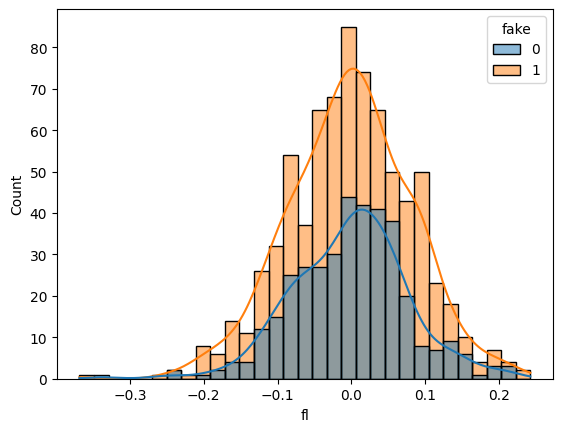

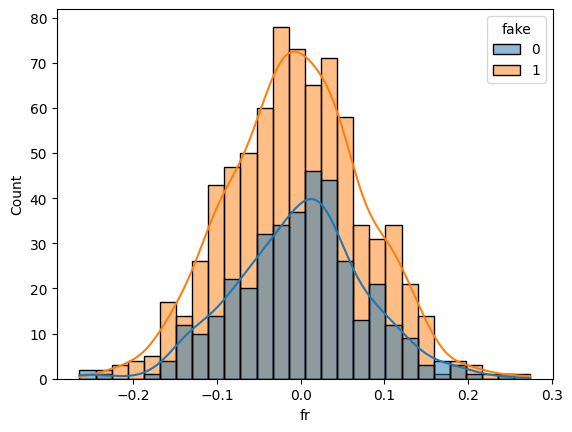

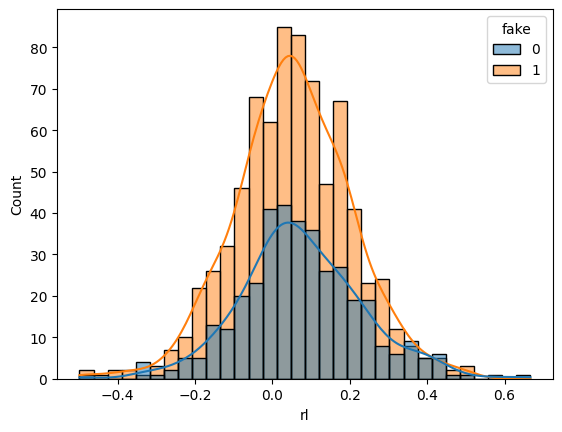

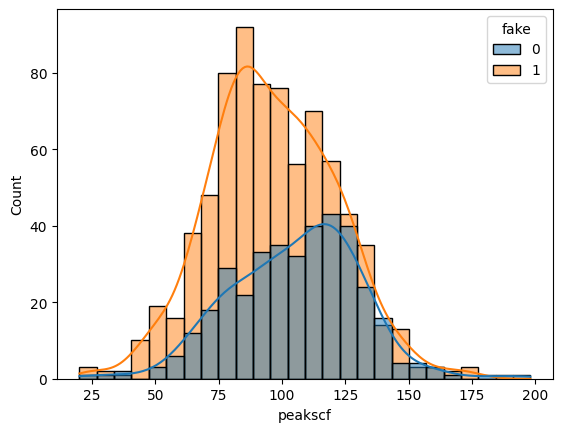

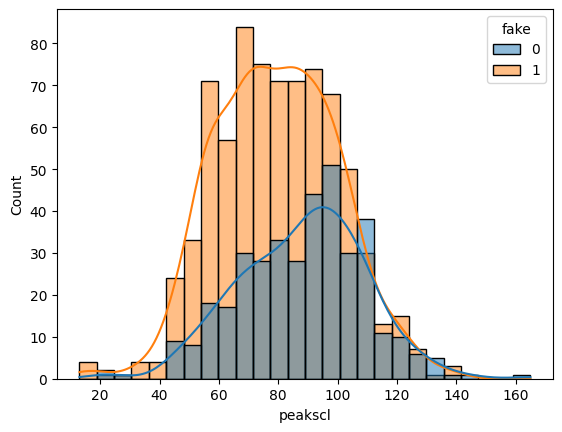

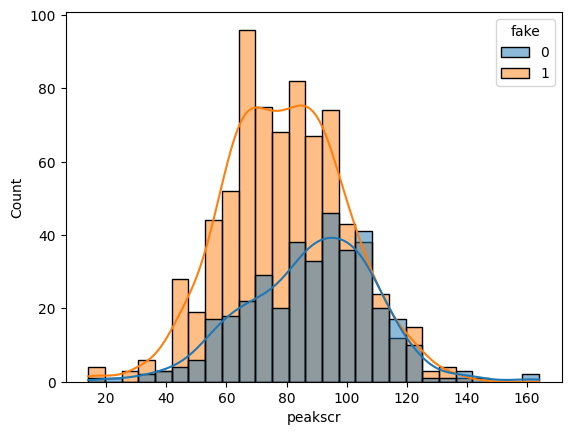

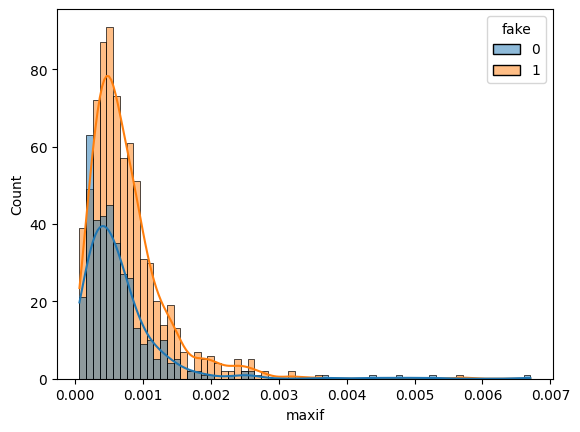

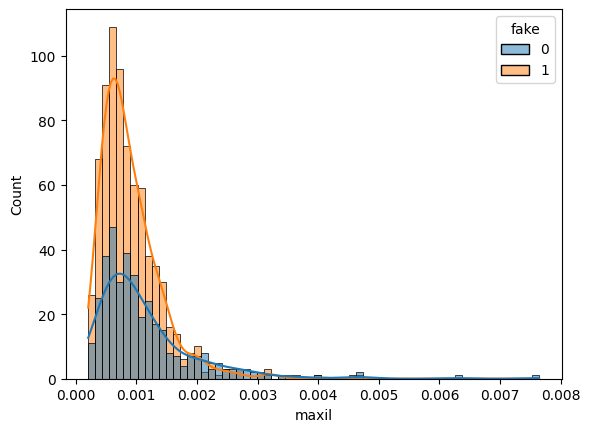

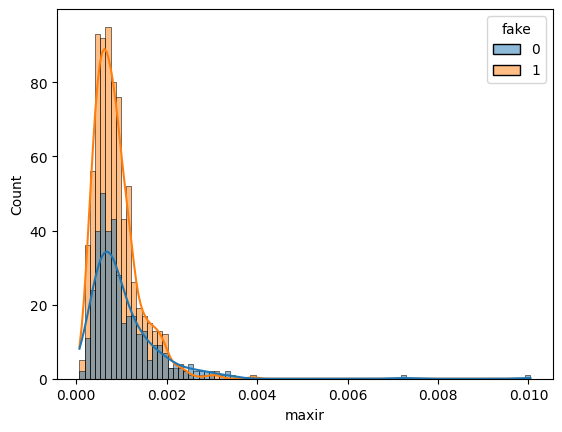

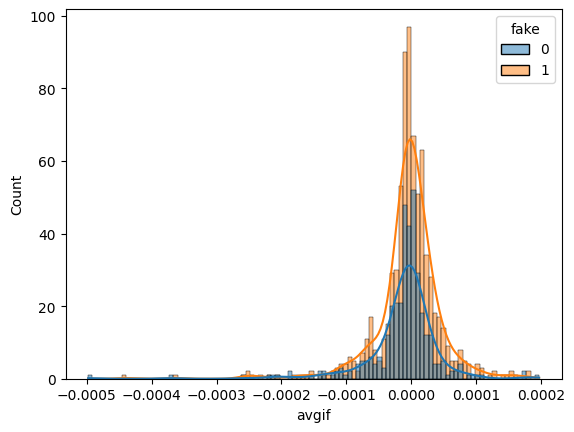

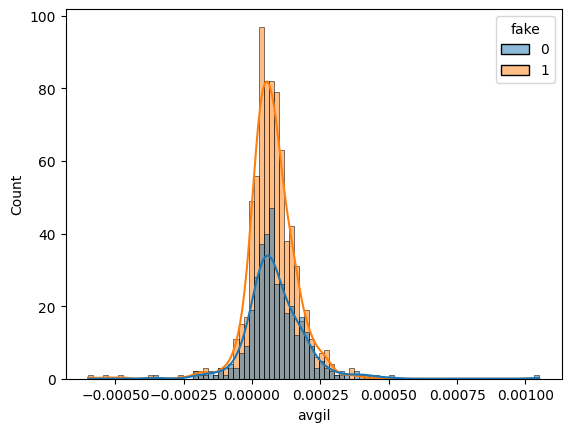

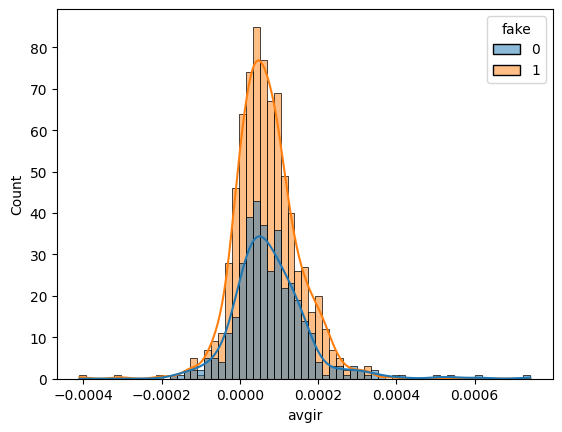

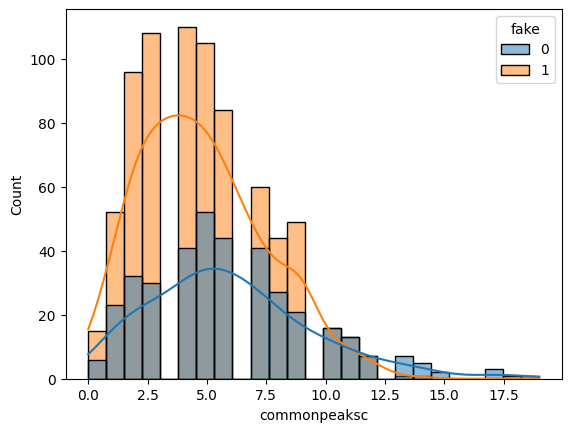

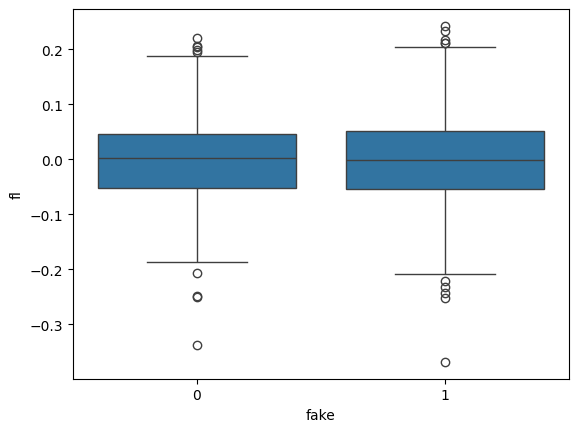

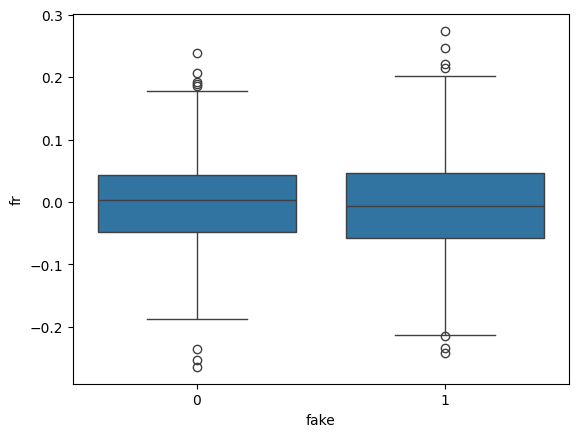

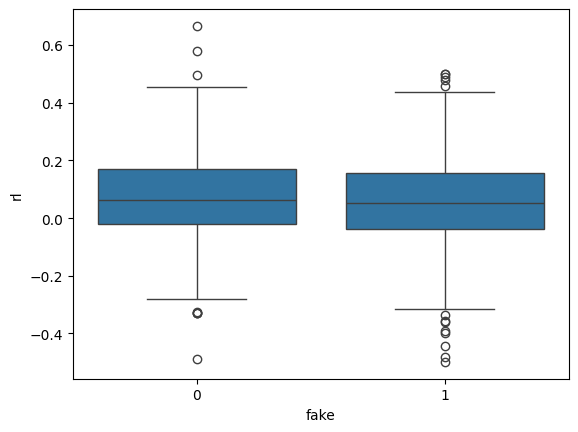

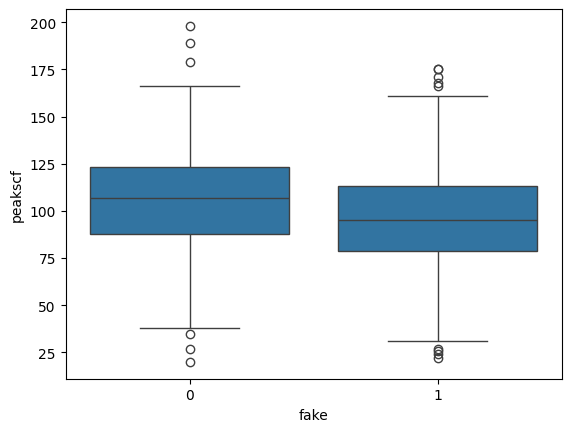

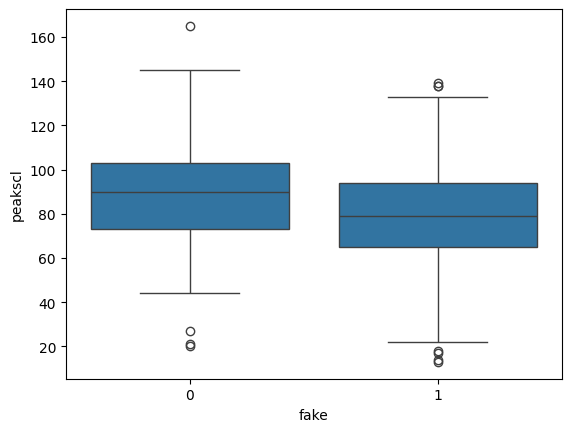

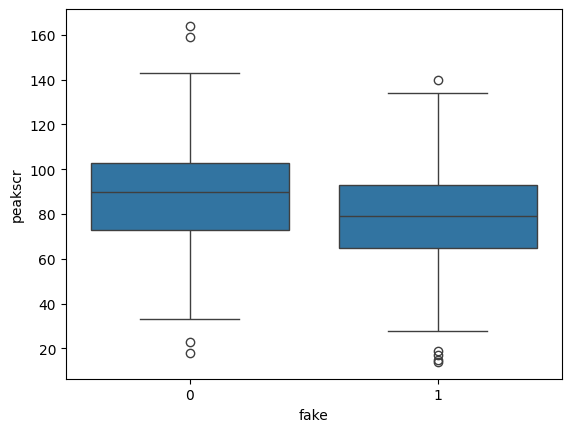

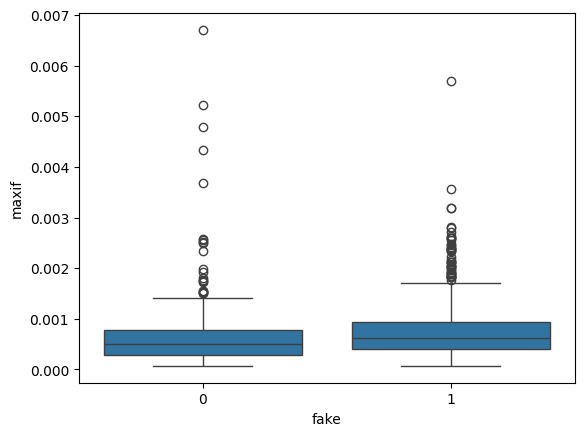

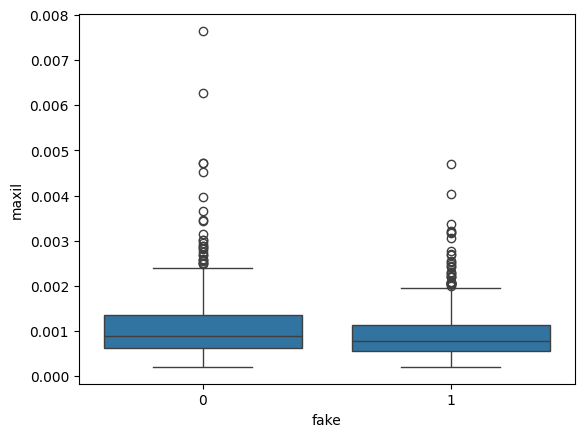

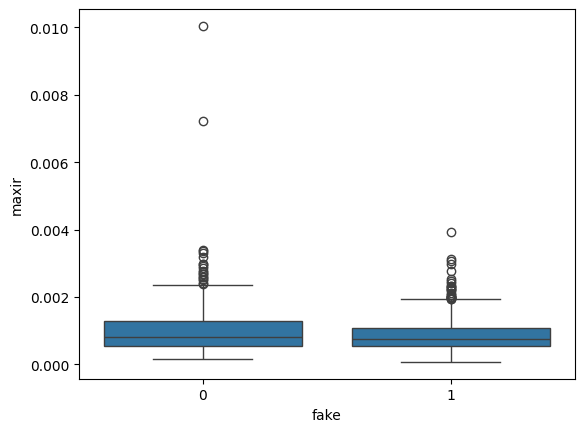

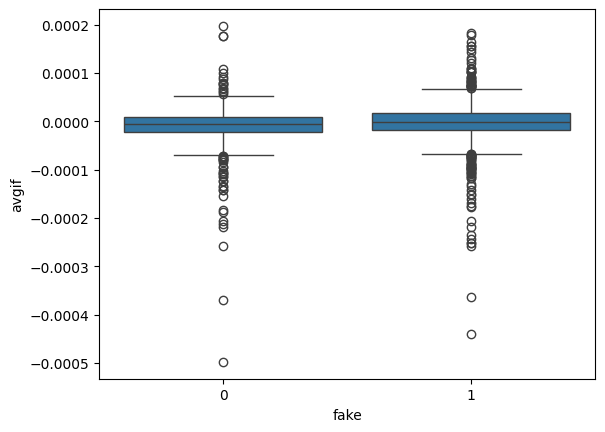

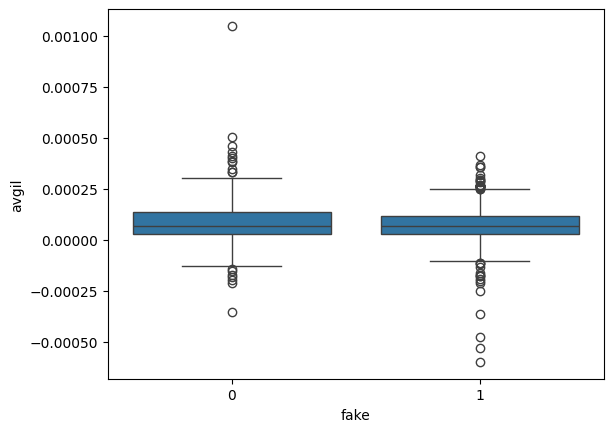

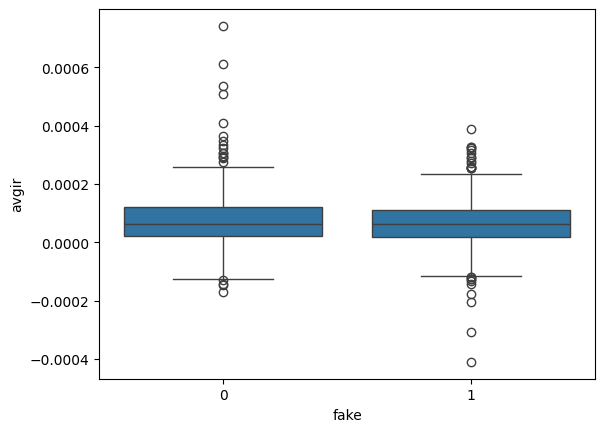

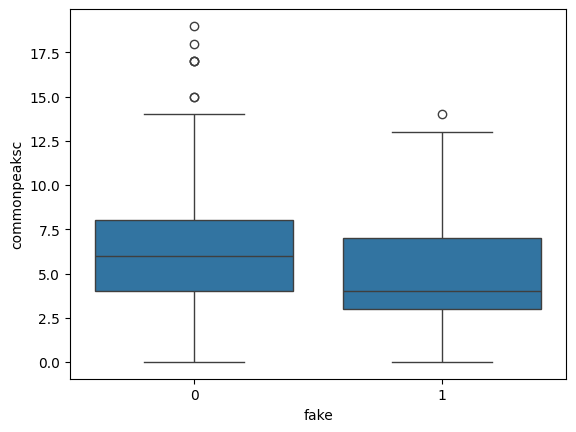

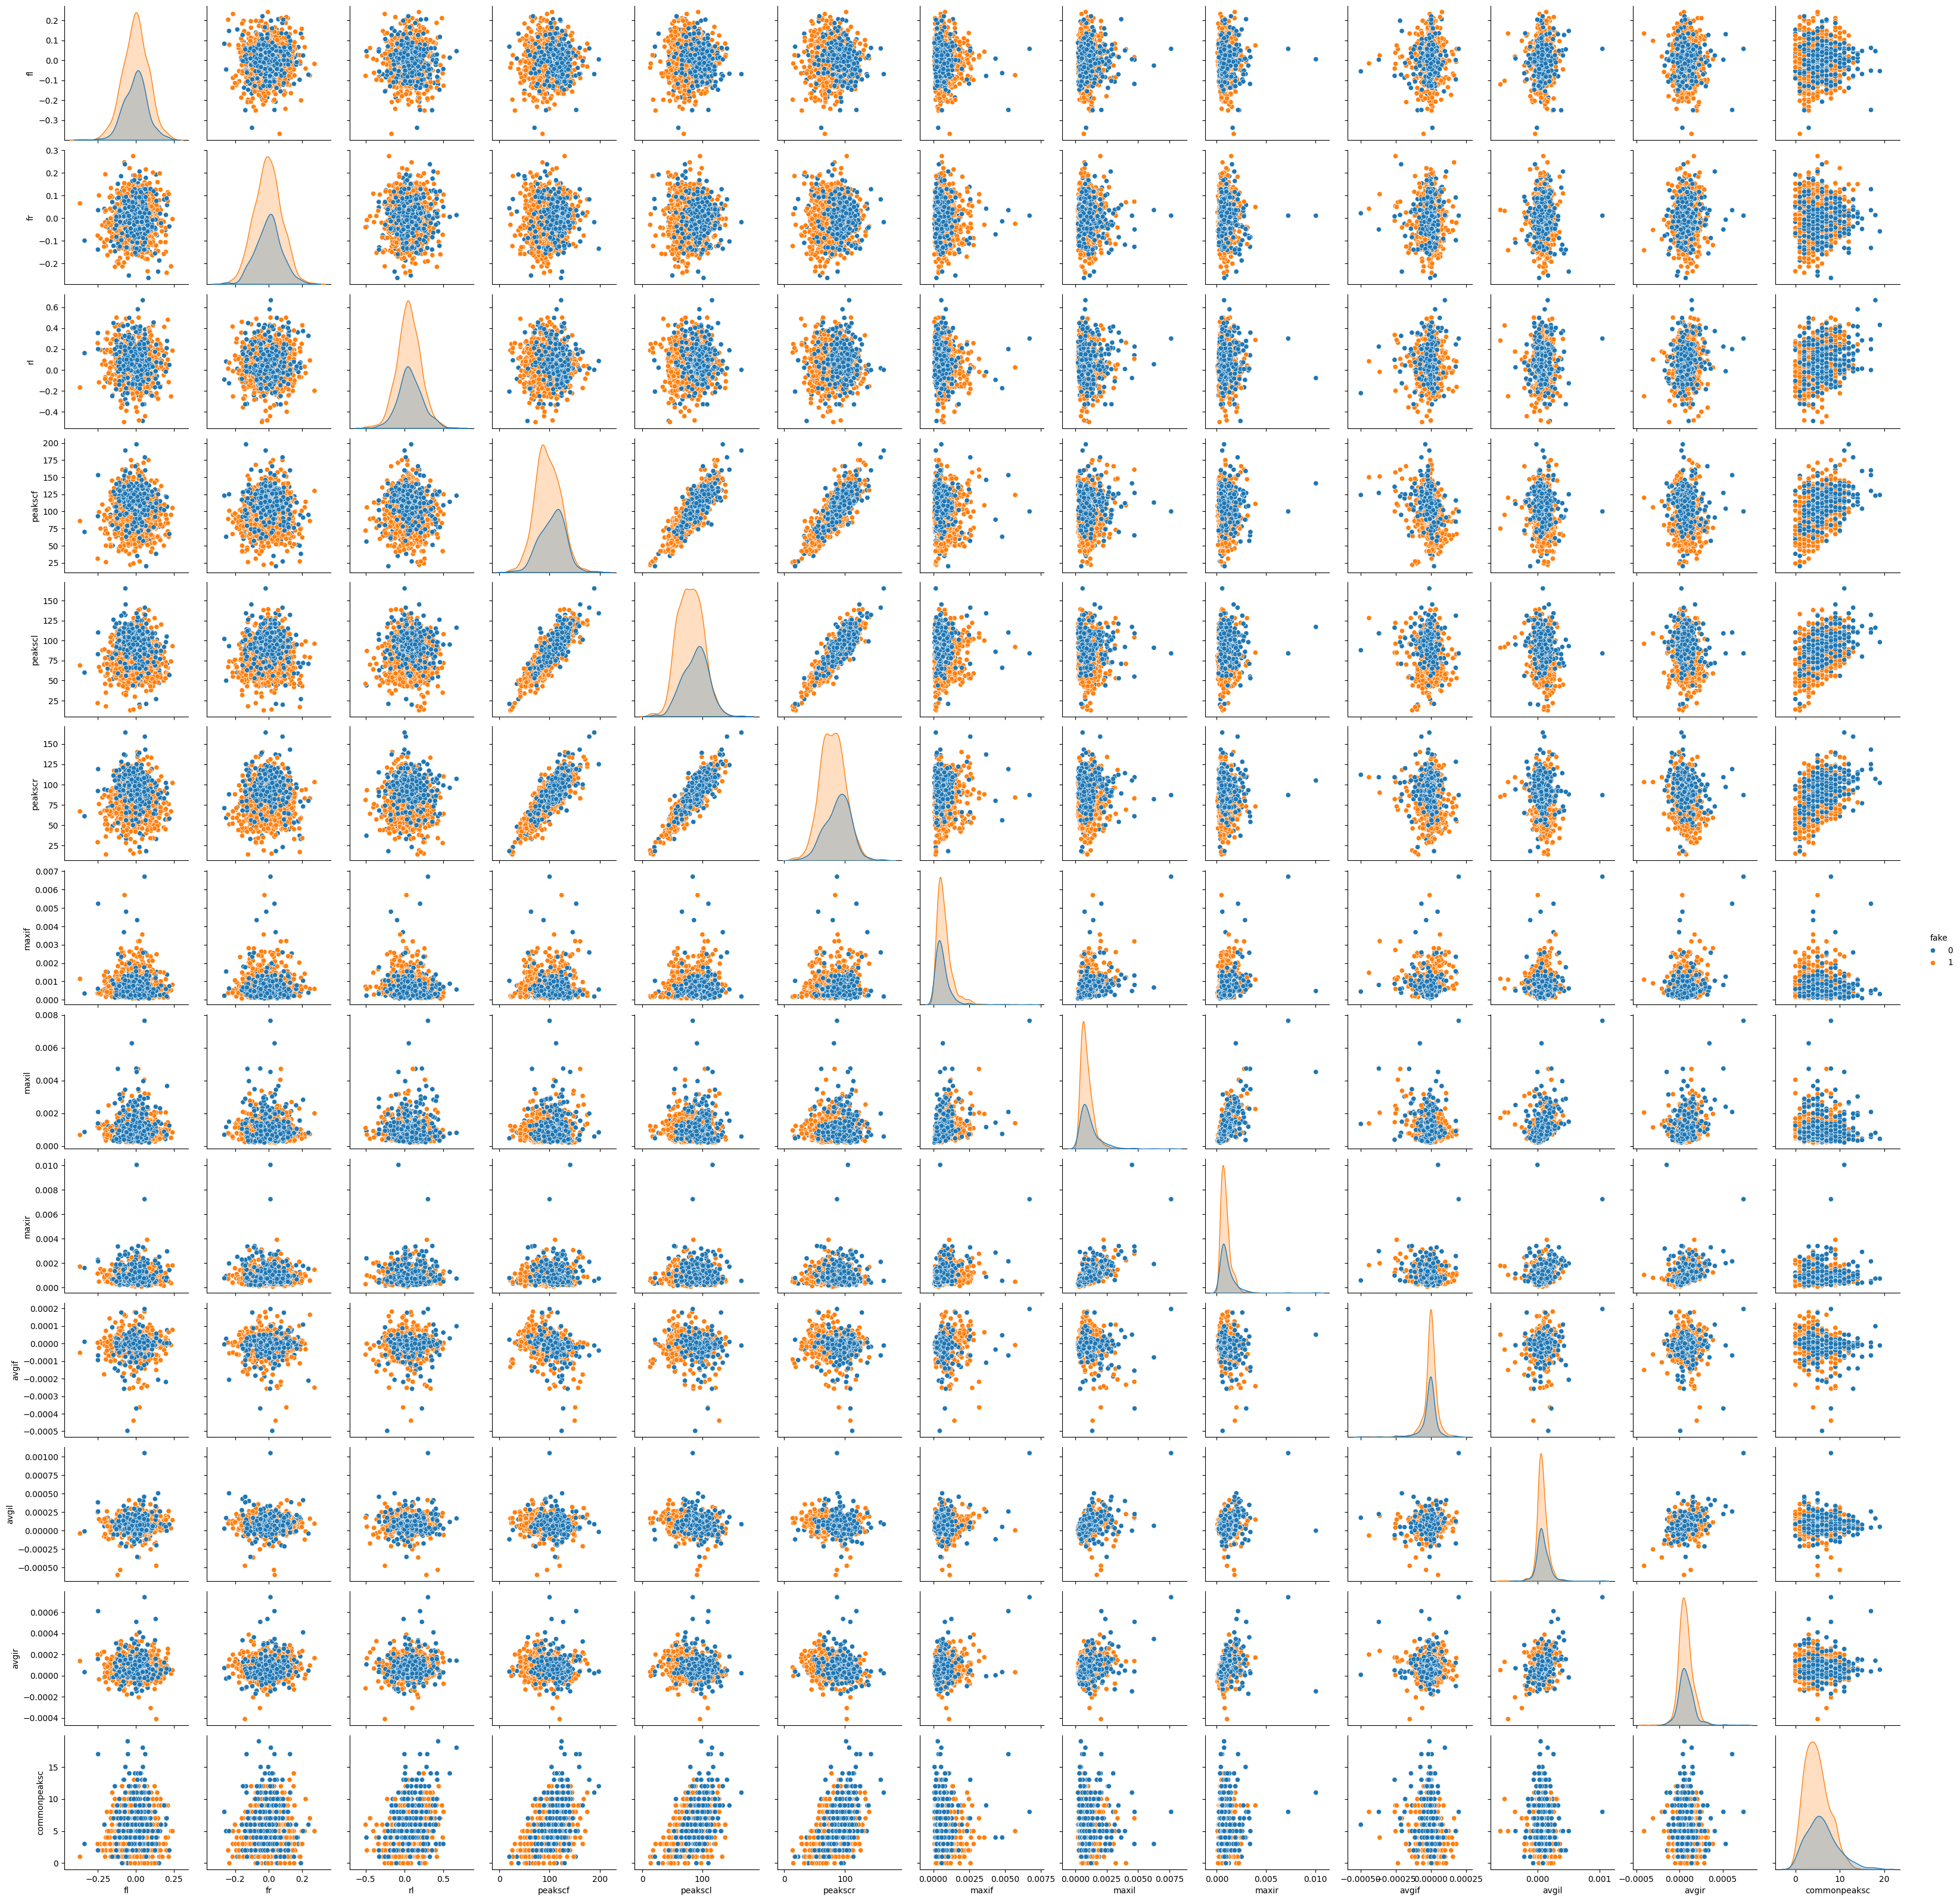

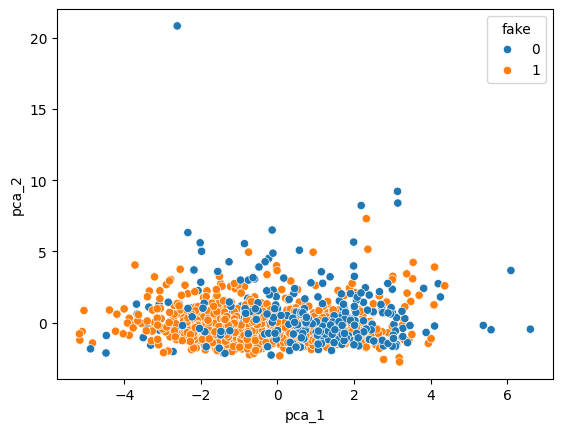

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load your data


# Summary statistics
print(udf.groupby('fake').describe())
df=udf
# Histograms
features = ['fl', 'fr', 'rl', 'peakscf', 'peakscl', 'peakscr', 'maxif', 'maxil',
       'maxir', 'avgif', 'avgil', 'avgir', 'commonpeaksc']
for feature in features:
    sns.histplot(data=df, x=feature, hue='fake', kde=True)
    plt.show()

# Box plots
for feature in features:
    sns.boxplot(x='fake', y=feature, data=df)
    plt.show()

# Pair plots
sns.pairplot(df, hue='fake', vars=features)
plt.show()

# PCA
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

df['pca_1'] = pca_result[:, 0]
df['pca_2'] = pca_result[:, 1]

sns.scatterplot(x='pca_1', y='pca_2', hue='fake', data=df)
plt.show()


In [35]:
import pandas as pd

# Load your data
df = udf

# Adjust display settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Summary statistics
summary = df.groupby('fake').describe()
print(summary)


         fl                                                              \
      count      mean       std       min       25%       50%       75%   
fake                                                                      
0     372.0 -0.001964  0.077694 -0.337909 -0.052098  0.002521  0.046102   
1     761.0 -0.002383  0.083782 -0.368291 -0.054264 -0.001720  0.050898   

                   fr                                                    \
           max  count      mean       std       min       25%       50%   
fake                                                                      
0     0.221109  372.0 -0.001037  0.077313 -0.264295 -0.048756  0.003083   
1     0.242364  761.0 -0.005458  0.080594 -0.241361 -0.058126 -0.006331   

                             rl                                         \
           75%       max  count      mean      std       min       25%   
fake                                                                     
0     0.043501  0.238166  

In [36]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load your data

# Extract features and target
features = ['fl', 'fr', 'rl', 'peakscf', 'peakscl', 'peakscr', 'maxif', 'maxil',
       'maxir', 'avgif', 'avgil', 'avgir', 'commonpeaksc']  # Add your feature columns here
target = 'fake'

# Normalize the feature columns
scaler = StandardScaler()
udf[features] = scaler.fit_transform(udf[features])


Decision Tree Metrics:
Accuracy: 0.6255506607929515
Precision: 0.6408851193769566
Recall: 0.6255506607929515
F1 Score: 0.632323845140376
------------------------------------
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.36      0.42      0.39        65
           1       0.75      0.71      0.73       162

    accuracy                           0.63       227
   macro avg       0.56      0.56      0.56       227
weighted avg       0.64      0.63      0.63       227

------------------------------------
Random Forest Metrics:
Accuracy: 0.7268722466960352
Precision: 0.7174342957679245
Recall: 0.7268722466960352
F1 Score: 0.7212079342139265
------------------------------------
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.53      0.46      0.49        65
           1       0.79      0.83      0.81       162

    accuracy                           0.

C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Metrics:
Accuracy: 0.6563876651982379
Precision: 0.6723780817682974
Recall: 0.6563876651982379
F1 Score: 0.6631880003046422
------------------------------------
Classification Report for AdaBoost:
              precision    recall  f1-score   support

           0       0.41      0.48      0.44        65
           1       0.78      0.73      0.75       162

    accuracy                           0.66       227
   macro avg       0.59      0.60      0.60       227
weighted avg       0.67      0.66      0.66       227

------------------------------------
Epoch 1/20


C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\keras\src\layers\core\dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5342 - loss: 0.8342 - val_accuracy: 0.1708 - val_loss: 0.8427
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5566 - loss: 0.7343 - val_accuracy: 0.1875 - val_loss: 0.8536
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6125 - loss: 0.7471 - val_accuracy: 0.2708 - val_loss: 0.8131
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5841 - loss: 0.7042 - val_accuracy: 0.2125 - val_loss: 0.8432
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6188 - loss: 0.6818 - val_accuracy: 0.2500 - val_loss: 0.8339
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6408 - loss: 0.6422 - val_accuracy: 0.3167 - val_loss: 0.8255
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6216 - loss: 0.6613 - val_accuracy: 0.2667 - val_loss: 0.8334
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6631 - loss: 0.6379 - val_accuracy: 0.2167 - val_loss: 0.8493
Epo

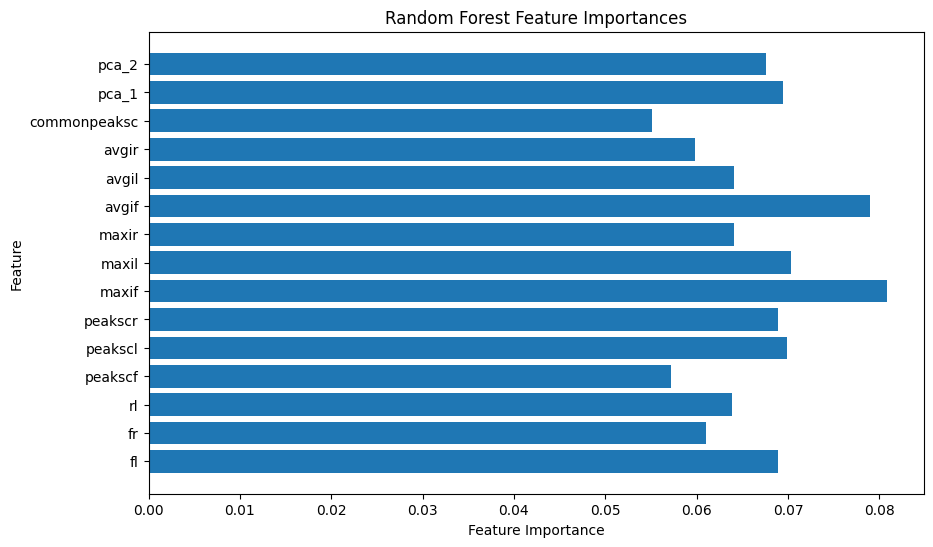

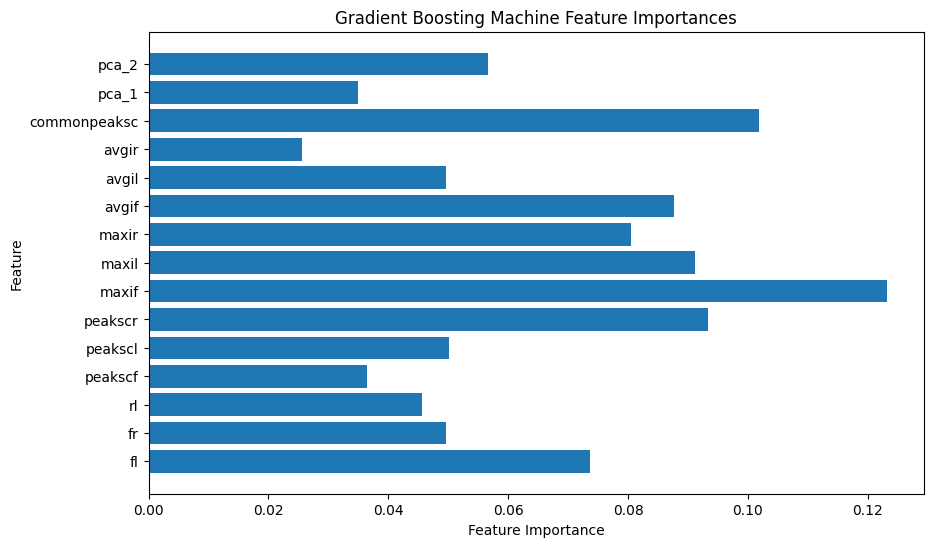

In [37]:
# Step 1: Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE  # Importing SMOTE
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Assuming the data is in a DataFrame named 'udf'
# Adjust this part according to your data loading method
X = udf.drop(columns=['fake'])  # Features
y = udf['fake']  # Target

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Converting the target variable to categorical (for neural network)
y_train_resampled_categorical = to_categorical(y_train_resampled)
y_test_categorical = to_categorical(y_test)

# Models initialization with class weight adjustment
models = {
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', class_weight='balanced', random_state=42),
    "GBM": GradientBoostingClassifier(random_state=42),  # GBM does not have class_weight parameter
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42)
}

# Dictionary to store results
results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

# Training, evaluating each model and storing results
for model_name, model in models.items():
    # Training
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predicting on the test set
    y_pred = model.predict(X_test)
    
    # Metrics calculation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Storing results
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)
    
    # Printing metrics
    print(f"{model_name} Metrics:")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print("------------------------------------")
    
    # Printing classification report
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred))
    print("------------------------------------")

# Creating and training a neural network
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Assuming binary classification (0 and 1)
])

nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train_resampled, y_train_resampled_categorical, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Predicting on the test set
y_pred_nn = nn_model.predict(X_test)
y_pred_nn_classes = tf.argmax(y_pred_nn, axis=1)

# Metrics calculation for neural network
accuracy_nn = accuracy_score(y_test, y_pred_nn_classes)
precision_nn = precision_score(y_test, y_pred_nn_classes, average='weighted')
recall_nn = recall_score(y_test, y_pred_nn_classes, average='weighted')
f1_nn = f1_score(y_test, y_pred_nn_classes, average='weighted')

# Storing neural network results
results['Model'].append('Neural Network')
results['Accuracy'].append(accuracy_nn)
results['Precision'].append(precision_nn)
results['Recall'].append(recall_nn)
results['F1 Score'].append(f1_nn)

# Printing neural network metrics
print("Neural Network Metrics:")
print(f"Accuracy: {accuracy_nn}")
print(f"Precision: {precision_nn}")
print(f"Recall: {recall_nn}")
print(f"F1 Score: {f1_nn}")
print("------------------------------------")

# Creating a DataFrame for results
results_df = pd.DataFrame(results)

# Displaying results table
print("\nResults Summary:")
print(results_df)

# Optionally, you can visualize additional plots if needed (e.g., confusion matrix, feature importance)

# Example: Confusion Matrix for Decision Tree
clf_dt = models['Decision Tree']
y_pred_dt = clf_dt.predict(X_test)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix (Decision Tree):")
print(conf_matrix_dt)

# Example: Feature Importance for Random Forest
clf_rf = models['Random Forest']
feature_importances = clf_rf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.show()

# Example: Feature Importance for GBM
clf_gbm = models['GBM']
feature_importances_gbm = clf_gbm.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances_gbm)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Gradient Boosting Machine Feature Importances')
plt.show()

Training and tuning Decision Tree...
Decision Tree Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Decision Tree Metrics:
Accuracy: 0.7180616740088106
Precision: 0.6749098918702442
Recall: 0.7180616740088106
F1 Score: 0.6380378258421384
------------------------------------
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.55      0.09      0.16        65
           1       0.73      0.97      0.83       162

    accuracy                           0.72       227
   macro avg       0.64      0.53      0.49       227
weighted avg       0.67      0.72      0.64       227

------------------------------------
Training and tuning Random Forest...
Random Forest Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Metrics:
Accuracy: 0.748898678414097
Precision: 0.7279312097594037
Recall: 0.748898678414097
F1 Score: 0.7177910902768846
------------------------------------
Class

C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\sklearn\ensemble\_weight_boostin

AdaBoost Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
AdaBoost Metrics:
Accuracy: 0.7400881057268722
Precision: 0.7205037349166825
Recall: 0.7400881057268722
F1 Score: 0.6871361846554459
------------------------------------
Classification Report for AdaBoost:
              precision    recall  f1-score   support

           0       0.65      0.20      0.31        65
           1       0.75      0.96      0.84       162

    accuracy                           0.74       227
   macro avg       0.70      0.58      0.57       227
weighted avg       0.72      0.74      0.69       227

------------------------------------
Training and tuning Neural Network...
Epoch 1/20


C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\keras\src\layers\core\dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5272 - loss: 0.8494 - val_accuracy: 0.6868 - val_loss: 0.5944
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6050 - loss: 0.7526 - val_accuracy: 0.7253 - val_loss: 0.5824
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5985 - loss: 0.7363 - val_accuracy: 0.7253 - val_loss: 0.5825
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6181 - loss: 0.6963 - val_accuracy: 0.7253 - val_loss: 0.5779
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5970 - loss: 0.7078 - val_accuracy: 0.7363 - val_loss: 0.5824
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5984 - loss: 0.6969 - val_accuracy: 0.7308 - val_loss: 0.5845
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5982 - loss: 0.7005 - val_accuracy: 0.7418 - val_loss: 0.5835
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6457 - loss: 0.6512 - val_accuracy: 0.7418 - val_loss: 0.5868
Ep

C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\keras\src\layers\core\dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4503 - loss: 0.8089 - val_accuracy: 0.7473 - val_loss: 0.5840
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6562 - loss: 0.6625 - val_accuracy: 0.7527 - val_loss: 0.5704
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6389 - loss: 0.6637 - val_accuracy: 0.7637 - val_loss: 0.5711
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6199 - loss: 0.6632 - val_accuracy: 0.7582 - val_loss: 0.5693
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6340 - loss: 0.6364 - val_accuracy: 0.7582 - val_loss: 0.5665
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6944 - loss: 0.6175 - val_accuracy: 0.7527 - val_loss: 0.5662
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6968 - loss: 0.6325 - val_accuracy: 0.7637 - val_loss: 0.5661
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6870 - loss: 0.6208 - val_accuracy: 0.7637 - val_loss: 0.5654
Ep

C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\keras\src\layers\core\dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5170 - loss: 0.6980 - val_accuracy: 0.7253 - val_loss: 0.5960
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6804 - loss: 0.6255 - val_accuracy: 0.7582 - val_loss: 0.5787
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6605 - loss: 0.6296 - val_accuracy: 0.7637 - val_loss: 0.5787
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6435 - loss: 0.6436 - val_accuracy: 0.7527 - val_loss: 0.5834
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6463 - loss: 0.6318 - val_accuracy: 0.7582 - val_loss: 0.5742
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6610 - loss: 0.6198 - val_accuracy: 0.7637 - val_loss: 0.5774
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6933 - loss: 0.5900 - val_accuracy: 0.7747 - val_loss: 0.5686
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7004 - loss: 0.5995 - val_accuracy: 0.7692 - val_loss: 0.5610
Ep

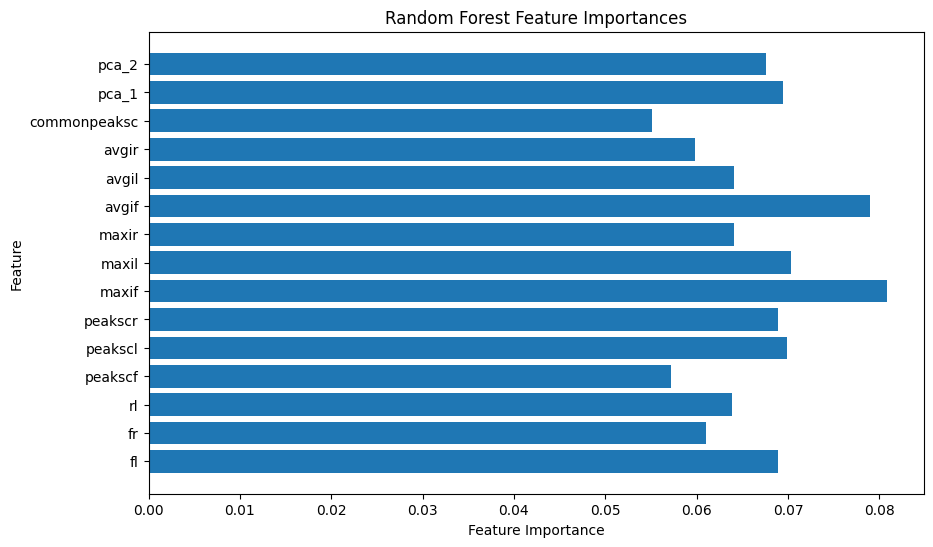

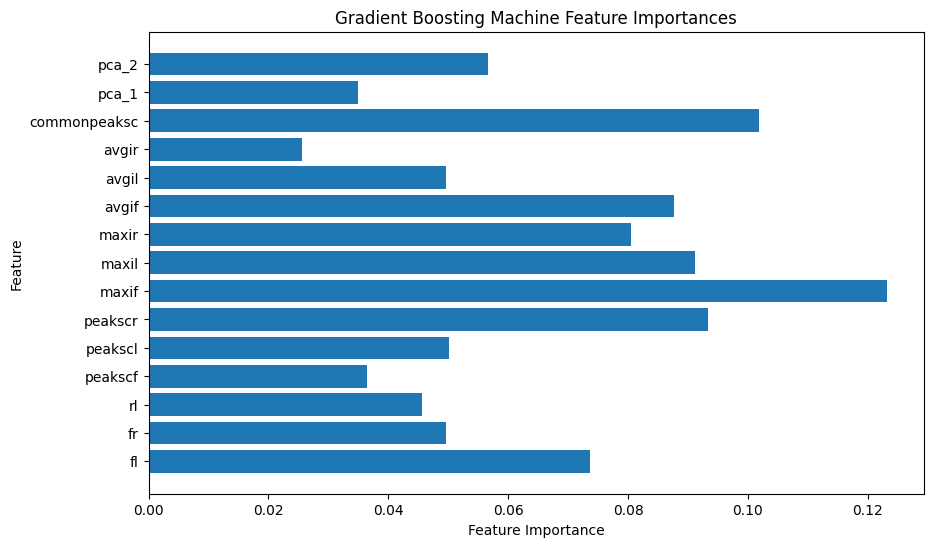

In [38]:
# Step 1: Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Assuming the data is in a DataFrame named 'udf'
# Adjust this part according to your data loading method
X = udf.drop(columns=['fake'])  # Features
y = udf['fake']  # Target

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter grids
param_grids = {
    "Decision Tree": {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]},
    "Random Forest": {'n_estimators': [100, 200], 'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]},
    "SVM": {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']},
    "GBM": {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 10]},
    "AdaBoost": {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]}
}

# Dictionary to store results
results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}

# Training, evaluating each model and storing results
for model_name, param_grid in param_grids.items():
    print(f"Training and tuning {model_name}...")
    if model_name == "Decision Tree":
        model = DecisionTreeClassifier(random_state=42)
    elif model_name == "Random Forest":
        model = RandomForestClassifier(random_state=42)
    elif model_name == "SVM":
        model = SVC(random_state=42)
    elif model_name == "GBM":
        model = GradientBoostingClassifier(random_state=42)
    elif model_name == "AdaBoost":
        model = AdaBoostClassifier(random_state=42)
    
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='f1_weighted')
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Metrics calculation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Storing results
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)
    
    # Printing metrics
    print(f"{model_name} Best Parameters: {grid_search.best_params_}")
    print(f"{model_name} Metrics:")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print("------------------------------------")
    
    # Printing classification report
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred))
    print("------------------------------------")

# Creating and training a neural network with hyperparameter tuning
print("Training and tuning Neural Network...")

# Hyperparameters for neural network
nn_param_grid = {
    'hidden_units': [(64, 32), (128, 64), (128, 64, 32)],
    'dropout_rates': [(0.5, 0.5), (0.4, 0.4), (0.3, 0.3)]
}

best_accuracy = 0
best_nn_model = None

for hidden_units, dropout_rates in zip(nn_param_grid['hidden_units'], nn_param_grid['dropout_rates']):
    nn_model = Sequential()
    nn_model.add(Dense(hidden_units[0], activation='relu', input_shape=(X_train.shape[1],)))
    nn_model.add(Dropout(dropout_rates[0]))
    nn_model.add(Dense(hidden_units[1], activation='relu'))
    nn_model.add(Dropout(dropout_rates[1]))
    if len(hidden_units) > 2:
        nn_model.add(Dense(hidden_units[2], activation='relu'))
        nn_model.add(Dropout(dropout_rates[1]))  # Using the same dropout rate for simplicity
    nn_model.add(Dense(2, activation='softmax'))  # Assuming binary classification (0 and 1)

    nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    nn_model.fit(X_train, to_categorical(y_train), epochs=20, batch_size=32, validation_split=0.2, verbose=1)
    
    y_pred_nn = nn_model.predict(X_test)
    y_pred_nn_classes = tf.argmax(y_pred_nn, axis=1)
    
    # Metrics calculation for neural network
    accuracy_nn = accuracy_score(y_test, y_pred_nn_classes)
    if accuracy_nn > best_accuracy:
        best_accuracy = accuracy_nn
        best_nn_model = nn_model

# Evaluating the best neural network model
y_pred_nn_best = best_nn_model.predict(X_test)
y_pred_nn_best_classes = tf.argmax(y_pred_nn_best, axis=1)
accuracy_nn_best = accuracy_score(y_test, y_pred_nn_best_classes)
precision_nn_best = precision_score(y_test, y_pred_nn_best_classes, average='weighted')
recall_nn_best = recall_score(y_test, y_pred_nn_best_classes, average='weighted')
f1_nn_best = f1_score(y_test, y_pred_nn_best_classes, average='weighted')

# Storing neural network results
results['Model'].append('Neural Network')
results['Accuracy'].append(accuracy_nn_best)
results['Precision'].append(precision_nn_best)
results['Recall'].append(recall_nn_best)
results['F1 Score'].append(f1_nn_best)

# Printing neural network metrics
print("Neural Network Metrics:")
print(f"Accuracy: {accuracy_nn_best}")
print(f"Precision: {precision_nn_best}")
print(f"Recall: {recall_nn_best}")
print(f"F1 Score: {f1_nn_best}")
print("------------------------------------")

# Creating a DataFrame for results
results_df = pd.DataFrame(results)

# Displaying results table
print("\nResults Summary:")
print(results_df)

# Optionally, you can visualize additional plots if needed (e.g., confusion matrix, feature importance)

# Example: Confusion Matrix for Decision Tree
clf_dt = models['Decision Tree']
y_pred_dt = clf_dt.predict(X_test)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix (Decision Tree):")
print(conf_matrix_dt)

# Example: Feature Importance for Random Forest
clf_rf = models['Random Forest']
feature_importances = clf_rf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.show()

# Example: Feature Importance for GBM
clf_gbm = models['GBM']
feature_importances_gbm = clf_gbm.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances_gbm)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Gradient Boosting Machine Feature Importances')
plt.show()

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


C:\Users\dpava\OneDrive\Documents\GitHub\HeartRate_Prediction\projectv\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Metrics after Hyperparameter Tuning:
Accuracy: 0.748898678414097
Precision: 0.7279312097594037
Recall: 0.748898678414097
F1 Score: 0.7177910902768846
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.31      0.41        65
           1       0.77      0.93      0.84       162

    accuracy                           0.75       227
   macro avg       0.70      0.62      0.63       227
weighted avg       0.73      0.75      0.72       227



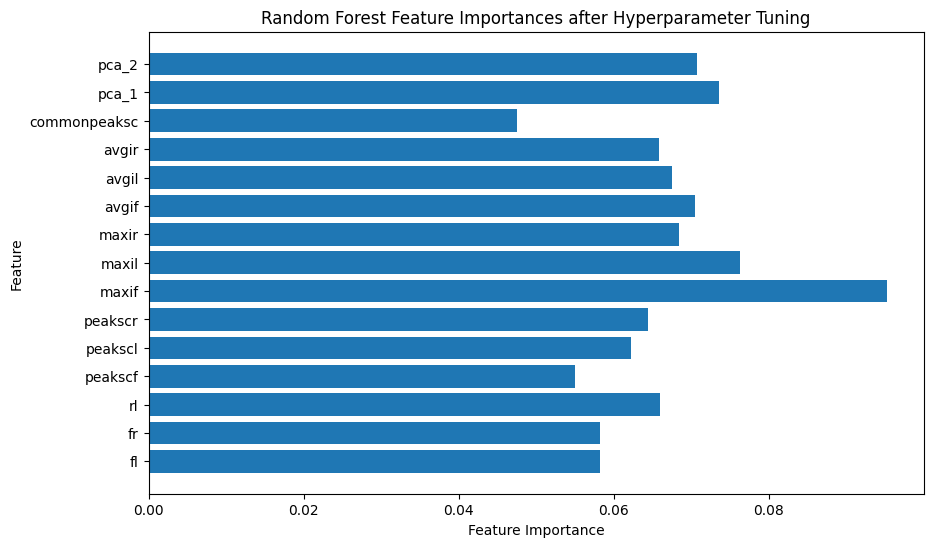

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the model
rf = RandomForestClassifier(random_state=42)

# Stratified K-Folds cross-validator
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=2, scoring='f1_weighted')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Best parameters
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Best estimator
best_rf = grid_search.best_estimator_

# Predictions and evaluation
y_pred = best_rf.predict(X_test)

# Metrics calculation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print metrics
print("Random Forest Metrics after Hyperparameter Tuning:")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
feature_importances = best_rf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances after Hyperparameter Tuning')
plt.show()